In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
data = pd.read_csv("/home/patel-krish/BrainyBeam/heart.csv")

In [14]:
numerical_columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

In [15]:
def mean(values):

    total = 0

    for value in values:
        total = total + value

    return total / len(values)

In [16]:
def correlation(x, y):

    x = list(x)
    y = list(y)

    mean_x = mean(x)
    mean_y = mean(y)

    numerator = 0
    x_square = 0
    y_square = 0

    for i in range(len(x)):

        x_difference = x[i] - mean_x
        y_difference = y[i] - mean_y

        numerator = numerator + (
            x_difference * y_difference
        )

        x_square = x_square + (
            x_difference ** 2
        )

        y_square = y_square + (
            y_difference ** 2
        )

    denominator = (
        x_square * y_square
    ) ** 0.5

    if denominator == 0:
        return 0

    return numerator / denominator

In [17]:
high_correlations = []

for i in range(len(numerical_columns)):

    for j in range(i + 1, len(numerical_columns)):

        column1 = numerical_columns[i]
        column2 = numerical_columns[j]

        corr_value = correlation(
            data[column1],
            data[column2]
        )

        if abs(corr_value) >= 0.5:

            high_correlations.append(
                [column1, column2, corr_value]
            )

In [18]:
for pair in high_correlations:

    print(
        pair[0],
        "and",
        pair[1],
        "=",
        round(pair[2], 2)
    )

oldpeak and slope = -0.58


In [21]:
def trendline(x, y):

    x = list(x)
    y = list(y)

    mean_x = mean(x)
    mean_y = mean(y)

    numerator = 0
    denominator = 0

    for i in range(len(x)):

        numerator = numerator + (
            (x[i] - mean_x) *
            (y[i] - mean_y)
        )

        denominator = denominator + (
            (x[i] - mean_x) ** 2
        )

    if denominator == 0:
        slope = 0

    else:
        slope = numerator / denominator

    intercept = mean_y - (
        slope * mean_x
    )

    return slope, intercept

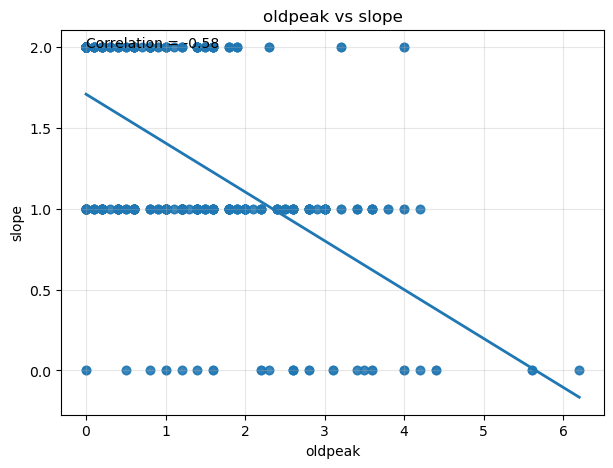

In [22]:
for pair in high_correlations:

    column1 = pair[0]
    column2 = pair[1]
    corr_value = pair[2]

    x = list(data[column1])
    y = list(data[column2])


    slope, intercept = trendline(x, y)


    minimum_x = x[0]
    maximum_x = x[0]

    for value in x:

        if value < minimum_x:
            minimum_x = value

        if value > maximum_x:
            maximum_x = value


    line_x = [
        minimum_x,
        maximum_x
    ]

    line_y = [
        slope * minimum_x + intercept,
        slope * maximum_x + intercept
    ]


    plt.figure(figsize=(7, 5))

    plt.scatter(
        x,
        y,
        alpha=0.5
    )


    plt.plot(
        line_x,
        line_y,
        linewidth=2
    )


    plt.title(
        column1 + " vs " + column2
    )

    plt.xlabel(column1)

    plt.ylabel(column2)


   
    plt.text(
        minimum_x,
        max(y),
        "Correlation = " +
        str(round(corr_value, 2))
    )


    plt.grid(alpha=0.3)

    plt.show()